In [63]:
import json
import os

import pandas as pd

# Plot the accuracy

dir = '../data/results/experiments/frequency_experiment_8'

errors_df = pd.read_csv(os.path.join(dir, 'errors.csv')).drop(columns=['Unnamed: 0'])
entries_df = pd.read_csv(os.path.join(dir, 'entries.csv')).drop(columns=['Unnamed: 0'])

dir = '../data/results/experiments/frequency_experiment_9'

errors_df_control = pd.read_csv(os.path.join(dir, 'errors.csv')).drop(columns=['Unnamed: 0'])
entries_df_control = pd.read_csv(os.path.join(dir, 'entries.csv')).drop(columns=['Unnamed: 0'])

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

In [64]:

from scripts.utils import operators_to_str, get_config

# Plotting with capped runtime data
param_str = f'RF Params: {config["rf_param"]}'
operator_str = f'Operators: {operators_to_str(config["operator_choice"])}'
title_string = f"wKNN with k-means clustering \n {param_str} * {operator_str} * {config['n_runs']} runs,"


def rename_cols(df, star: bool = False) -> dict[int, str]:
    if star:
        return {col: 'all*' if int(col) == 0 else str(col) + "*" for col in df.columns}
    return {col: 'all' if int(col) == 0 else str(col) for col in df.columns}


errors_df = errors_df.rename(columns=rename_cols(errors_df))
entries_df = entries_df.rename(columns=rename_cols(entries_df))
errors_df_control = errors_df_control.rename(columns=rename_cols(errors_df_control, star=True))
entries_df_control = entries_df_control.rename(columns=rename_cols(entries_df_control, star=True))


def merge_alternate(list1, list2):
    return [x for pair in zip(list1, list2) for x in pair]

In [110]:
from typing import Union
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def make_boxplot(
        df: pd.DataFrame,
        title: str,
        x_label: str,
        y_label: str,
        color: Union[str, dict] = "forestgreen",
        baseline: float = None,
        annotate: bool = False,
):
    """
    Creates a boxplot of the given dataframe.

    :param baseline:
    :param df:
    :param title:
    :param x_label:
    :param y_label:
    :param color: Color of the boxes
    """
    data_values = [df[col] for col in df.columns]
    means = [df[col].mean() for col in df.columns]
    num_boxes = len(df.columns)

    plt.figure(figsize=(20, 14))
    median_props = dict(color="black", linewidth="3")
    plot = plt.boxplot(
        data_values,
        patch_artist=True,
        tick_labels=df.columns,
        medianprops=median_props,
    )

    # Handle color assignment
    if isinstance(color, dict):
        for patch, col_name in zip(plot["boxes"], df.columns):
            patch.set_facecolor(color.get(col_name.strip('*'), "forestgreen"))
    else:
        for patch in plot["boxes"]:
            patch.set_facecolor(color)

    for patch, col_name in zip(plot["boxes"], df.columns):
        if col_name[-1] == '*':
            patch.set_hatch('o')
        else:
            patch.set_hatch('/')

    legend_elements = []

    # Add boxes to legend
    for col_name in df.columns:
        hatch = 'o' if col_name[-1] == '*' else '/'
        box_color = color.get(col_name.strip('*'), "forestgreen") if isinstance(color, dict) else color

        label = f'{col_name[:-1]} MHz (best beam)' if col_name[-1] == '*' else f'{col_name} MHz'
        label = f'All frequencies {label.split("all MHz")[1]}' if label.startswith('all MHz') else label
        patch = mpatches.Patch(
            facecolor=box_color,
            hatch=hatch,
            label=label
        )
        legend_elements.append(patch)

    if baseline:
        plt.axhline(
            y=baseline,
            color="red",
            linestyle="-",
            linewidth=2,
            label="Baseline",
        )
        plt.legend(loc="upper right")

    if annotate:
        text_offset = 0.22 if num_boxes < 4 else 0.5

        for i, mean in enumerate(means, 1):
            plt.text(
                i + text_offset,
                mean,
                f"\n{mean:.2f}",
                horizontalalignment="right",
                verticalalignment="center",
                color="black",
            )

    # formatting the plot
    plt.title(title)
    plt.grid(axis="y")
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.legend(handles=legend_elements, loc='upper right')
    plt.margins(y=0.2)

    # Show the plot
    plt.show()




In [111]:
from matplotlib.lines import Line2D


def make_barplot(
        df: pd.DataFrame,
        title: str,
        x_label: str,
        y_label: str,
        color: Union[str, dict] = "skyblue",
        baseline: float = None,
        annotate: bool = False,
):
    """
    Creates a bar plot of the given dataframe.
    """
    if df.empty:
        raise ValueError("The DataFrame is empty.")

    means = df.mean()

    plt.figure(figsize=(20, 12))

    # Handle color assignment
    if isinstance(color, dict):
        colors = [color.get(col.strip('*'), "forestgreen") for col in means.index]
        hatches = ['o' if col[-1] == '*' else '/' for col in means.index]
        bars = plt.bar(
            range(len(means)), means.values, color=colors, tick_label=means.index, hatch=hatches,
        )
    else:
        bars = plt.bar(
            range(len(means)), means.values, color=color, tick_label=means.index
        )

    # Create legend elements
    legend_elements = []

    # Add bars to legend
    for col_name in means.index:
        bar_color = color.get(col_name.strip('*'), "forestgreen") if isinstance(color, dict) else color
        hatch = 'o' if col_name[-1] == '*' else '/'
        label = f'{col_name[:-1]} MHz (best beam)' if col_name[-1] == '*' else f'{col_name} MHz'
        label = f'All frequencies {label.split("all MHz")[1]}' if label.startswith('all MHz') else label

        patch = mpatches.Patch(
            facecolor=bar_color,
            label=label,
            hatch=hatch,
        )
        legend_elements.append(patch)

    # Add baseline to legend if it exists
    if baseline is not None:
        legend_elements.append(Line2D([0], [0], color='red', linestyle='-', linewidth=2, label='Baseline'))

    # Add the legend
    plt.legend(handles=legend_elements, loc='upper left', ncol=2)

    if annotate:
        for i, bar in enumerate(bars):
            height = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{height:.0f}",
                ha="center",
                va="bottom",
            )

    # Formatting the plot
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.yscale("log")

    def thousands_formatter(x, pos):
        return f"{x / 1000:.0f}k"

    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(thousands_formatter))
    plt.tight_layout()
    plt.grid(axis="y")

    # Show the plot
    plt.show()


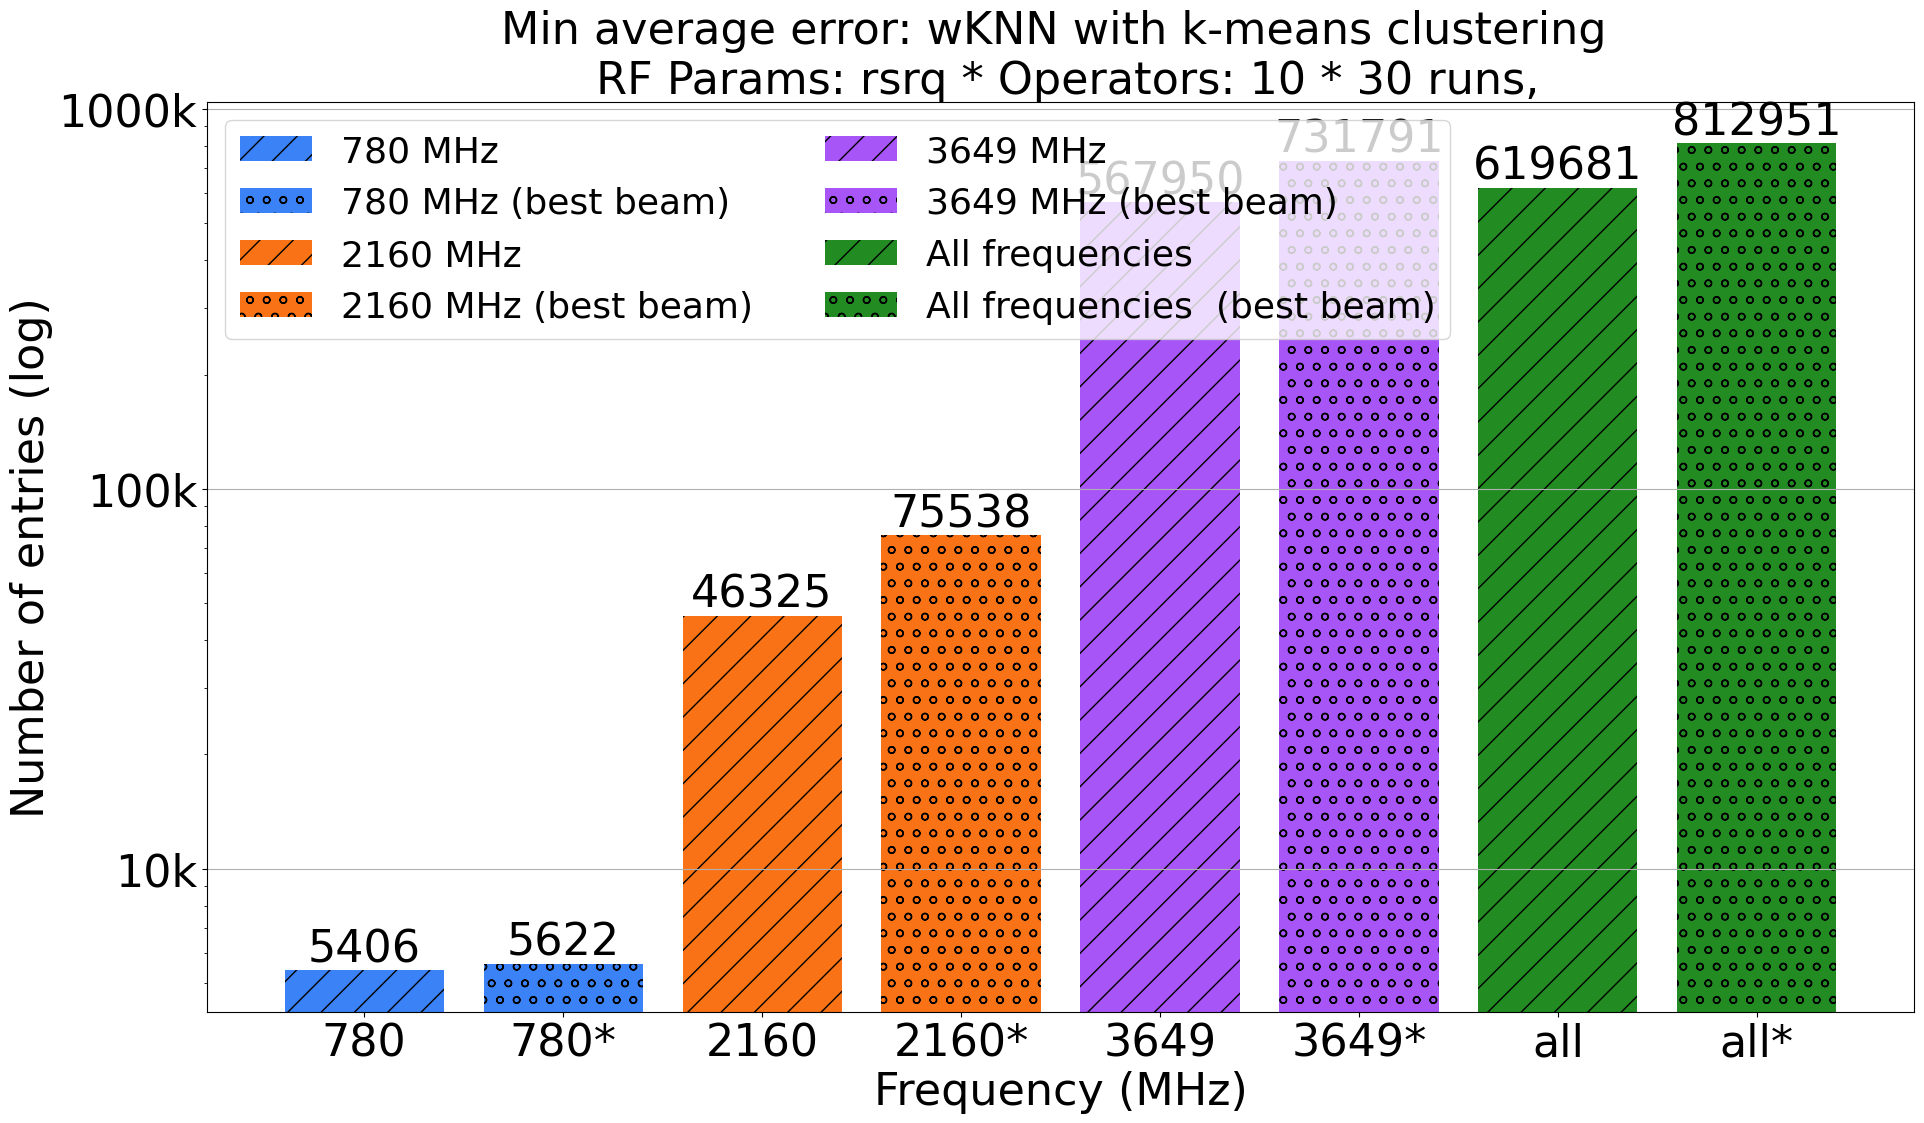

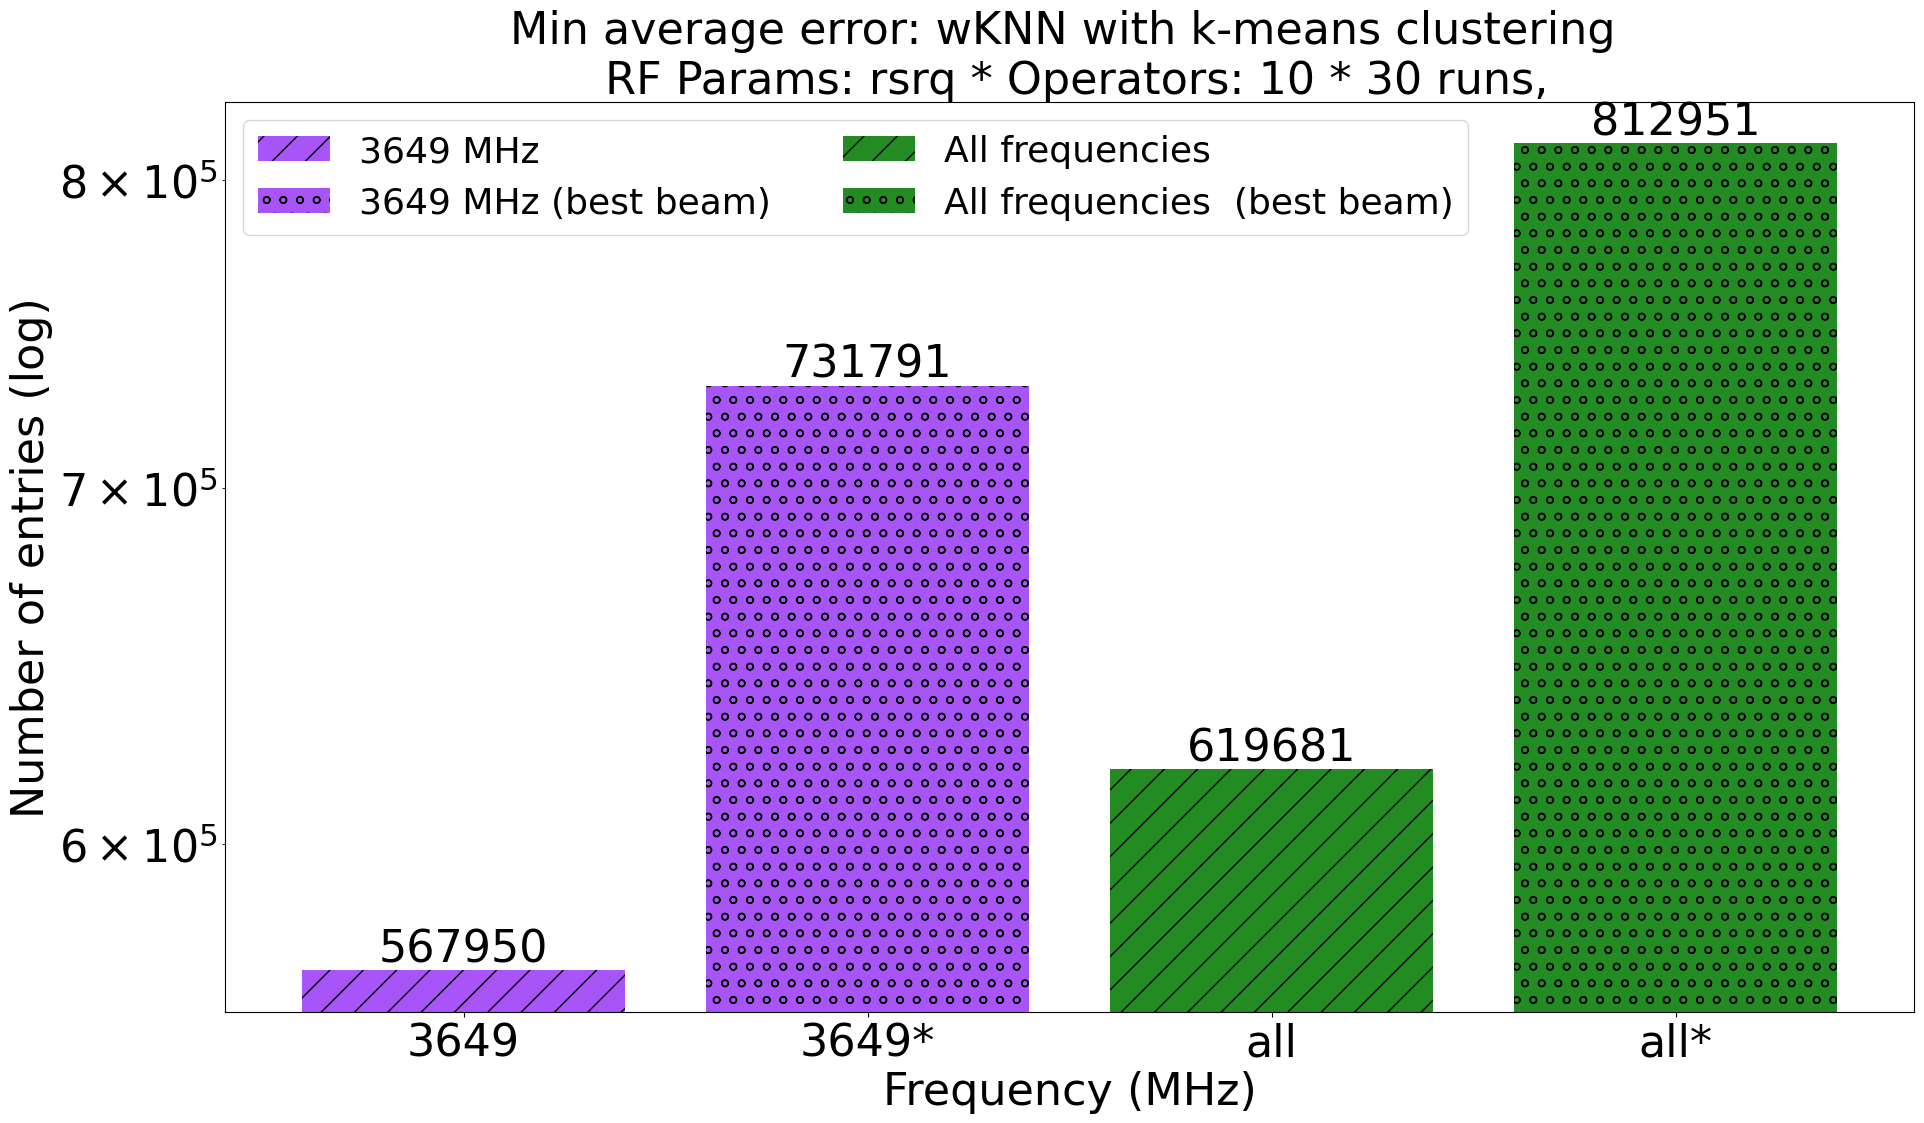

In [113]:
color_map = get_config("color_map.json", "frequency")

column_orders = [
    ['780', '2160', '3649', 'all'],
    ['3649', 'all']
]

for order in column_orders:
    star_order = list(map(lambda x: x + "*", order))

    all_cols = merge_alternate(order, star_order)

    all_errors = pd.concat([errors_df, errors_df_control], axis=1)[all_cols]
    all_entries = pd.concat([entries_df, entries_df_control], axis=1)[all_cols]

    # make_boxplot(
    #     df=all_errors,
    #     title=f'Min average error: {title_string}',
    #     x_label='Frequency (MHz)',
    #     y_label='Error (m)',
    #     color=color_map,
    # )

    make_barplot(
        df=all_entries,
        title=f'Min average error: {title_string}',
        x_label='Frequency (MHz)',
        y_label='Number of entries (log)',
        color=color_map,
        annotate=True,
    )

